# Exercise 2 - Multiclass Classification with Keras

- Id: 22302421
- Full name: Nguyễn Phúc Minh Châu

This notebook is a practice exercise for **multiclass classification** using **Keras**.

Dataset: Wine Dataset (3 classes)


## Requirements

Requirement 1: Load the Wine dataset from scikit-learn.

Requirement 2: Split the dataset into training and test sets.

Requirement 3: Normalize the input features.

Requirement 4: Convert class labels into one-hot encoding.

Requirement 5: Build a neural network for multiclass classification using Keras.

Requirement 6: Train the model with validation data.

Requirement 7: Plot training and validation loss and accuracy.

Requirement 8: Evaluate the model using Confusion Matrix and Classification Report.


In [1]:
# Import các thư viện cần thiết
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

I0000 00:00:1778210775.985667   76418 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778210776.046541   76418 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778210777.529334   76418 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Step 1: Load Dataset

Load the Wine dataset.
Extract input features X and class labels y.


In [2]:
# TODO: Load Wine dataset
data = load_wine()
X = data.data
y = data.target

print("Input shape:", X.shape)
print("Number of classes:", len(np.unique(y)))

Input shape: (178, 13)
Number of classes: 3


## Step 2: Data Preprocessing

Split the dataset into training and test sets.
Apply feature scaling.
Convert labels to one-hot encoding.


In [3]:
# TODO: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TODO: Feature scaling using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# TODO: One-hot encode labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

## Step 3: Build Neural Network Model

Build a neural network for multiclass classification.
Use Softmax activation in the output layer.


In [4]:
# Khởi tạo mô hình
model = Sequential()

# TODO: Add hidden layers
model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))

# TODO: Add output layer with softmax activation
model.add(Dense(y_train.shape[1], activation='softmax'))

# TODO: Compile the model with categorical_crossentropy
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

/home/zhu/micromamba/envs/tf/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1778210851.097133   76418 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Step 4: Train the Model

Train the model using training data.
Use validation_split to monitor model performance.


In [5]:
# TODO: Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.3540 - loss: 1.5234 - val_accuracy: 0.4828 - val_loss: 1.2480
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3805 - loss: 1.3933 - val_accuracy: 0.5172 - val_loss: 1.1408
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4248 - loss: 1.2861 - val_accuracy: 0.5517 - val_loss: 1.0453
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4425 - loss: 1.1842 - val_accuracy: 0.6207 - val_loss: 0.9561
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4779 - loss: 1.0938 - val_accuracy: 0.6207 - val_loss: 0.8757
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5221 - loss: 1.0148 - val_accuracy: 0.6552 - val_loss: 0.8068
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5575 - loss: 0.9436 - val_accuracy: 0.6897 - val_loss: 0.7471
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5841 - loss: 0.8827 - val_accuracy: 0.7931 - val_loss: 0.6948


## Step 5: Visualization

Plot training and validation loss.
Plot training and validation accuracy.


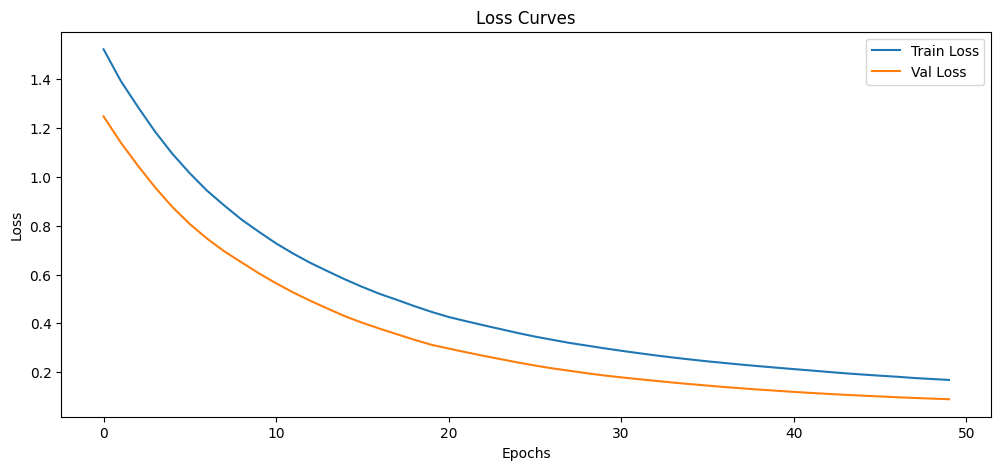

In [6]:
# TODO: Plot loss and accuracy curves
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Step 6: Model Evaluation

Evaluate the model on the test set.
Compute Confusion Matrix and Classification Report.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


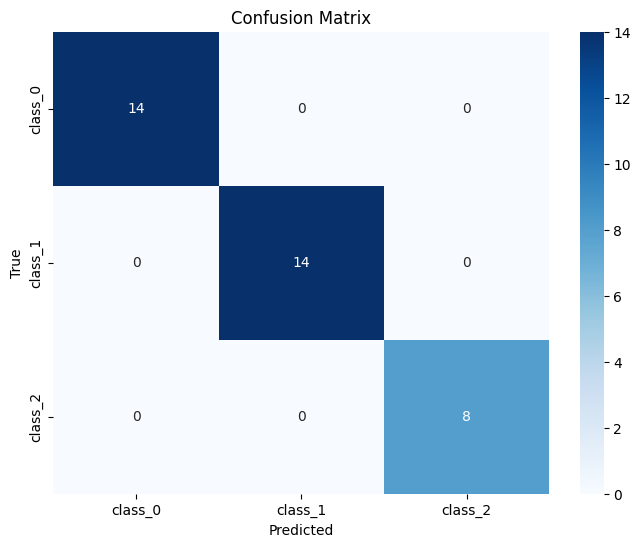

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        14
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [8]:
# TODO: Predict class probabilities on test data
y_pred = model.predict(X_test)

# TODO: Convert predictions to class labels
y_pred_labels = np.argmax(y_pred, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

# TODO: Confusion Matrix
cm = confusion_matrix(y_test_labels, y_pred_labels)

# TODO: Visualize Confusion Matrix using heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
# TODO: Print classification report
print(classification_report(y_test_labels, y_pred_labels, target_names=data.target_names))

## Questions for Students

**Question 1: Why is Softmax used in the output layer for multiclass classification?**
    
Softmax is used in the output layer for multiclass classification because it converts the raw output scores (logits) from the neural network into probabilities that sum to 1. This allows us to interpret the output as the likelihood of each class being the correct one, which is essential for making predictions in a multiclass setting.

**Question 2: What is the role of one-hot encoding in training neural networks?**
    
One-hot encoding is used to convert categorical labels into a binary matrix representation. This is important for training neural networks because it allows the model to output a probability distribution over the classes. Each class is represented as a vector where only the index corresponding to the class is set to 1, and all other indices are set to 0. This format is compatible with loss functions like categorical crossentropy, which require the target labels to be in a one-hot encoded format.

**Question 3: How does increasing the number of hidden layers affect model performance?**
    
Increasing the number of hidden layers can allow the model to learn more complex patterns in the data, potentially improving performance. However, it can also lead to overfitting if the model becomes too complex relative to the amount of training data. Additionally, deeper networks may require more computational resources and longer training times. It's important to find a balance between model complexity and generalization to achieve optimal performance.

